In [ ]:
import pandas as pd

# Cargar los datos
df_train = pd.read_csv("twitter_training.csv")
df_val = pd.read_csv("twitter_validation.csv")

# Ver cómo se ven los datos
print("Training:", df_train.shape)
print("Validation:", df_val.shape)
df_train.head()

Training: (74681, 4)
Validation: (999, 4)


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
# Ponerle nombres a las columnas
columnas = ["id", "tema", "sentimiento", "texto"]

df_train.columns = columnas
df_val.columns = columnas

# Ver cómo quedó
df_train.head()

,id,tema,sentimiento,texto
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
# Ver qué tipos de sentimiento existen
print(df_train["sentimiento"].value_counts())

sentimiento
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [ ]:
# Eliminar los tweets irrelevantes
df_train = df_train[df_train["sentimiento"] != "Irrelevant"]
df_val = df_val[df_val["sentimiento"] != "Irrelevant"]

# Verificar que se eliminaron
print(df_train["sentimiento"].value_counts())

sentimiento
Negative    22542
Positive    20831
Neutral     18318
Name: count, dtype: int64


In [ ]:
import re

# Función para limpiar cada tweet
def limpiar_texto(texto):
    texto = str(texto).lower()           # todo a minúsculas
    texto = re.sub(r"http\S+", "", texto)  # quitar links
    texto = re.sub(r"@\w+", "", texto)     # quitar menciones
    texto = re.sub(r"#\w+", "", texto)     # quitar hashtags
    texto = re.sub(r"[^a-z\s]", "", texto) # quitar símbolos y números
    return texto

# Aplicar la limpieza
df_train["texto_limpio"] = df_train["texto"].apply(limpiar_texto)
df_val["texto_limpio"] = df_val["texto"].apply(limpiar_texto)

# Ver cómo quedó
df_train[["texto", "texto_limpio"]].head()

,texto,texto_limpio
0,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear el vectorizador
vectorizador = TfidfVectorizer(max_features=5000)

# Convertir el texto a números
X_train = vectorizador.fit_transform(df_train["texto_limpio"])
X_val = vectorizador.transform(df_val["texto_limpio"])

# Las etiquetas (lo que queremos predecir)
y_train = df_train["sentimiento"]
y_val = df_val["sentimiento"]

print("Listo! Forma de los datos:", X_train.shape)

Listo! Forma de los datos: (61691, 5000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Modelo 1: Naive Bayes
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)
predicciones_nb = modelo_nb.predict(X_val)
accuracy_nb = accuracy_score(y_val, predicciones_nb)
print("Naive Bayes:", round(accuracy_nb * 100, 2), "%")

# Modelo 2: Logistic Regression
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
predicciones_lr = modelo_lr.predict(X_val)
accuracy_lr = accuracy_score(y_val, predicciones_lr)
print("Logistic Regression:", round(accuracy_lr * 100, 2), "%")

Naive Bayes: 75.85 %
Logistic Regression: 85.99 %


In [ ]:
from sklearn.metrics import classification_report

print("=== Naive Bayes ===")
print(classification_report(y_val, predicciones_nb))

print("=== Logistic Regression ===")
print(classification_report(y_val, predicciones_lr))

=== Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.69      0.85      0.76       266
     Neutral       0.84      0.59      0.70       285
    Positive       0.77      0.84      0.80       277

    accuracy                           0.76       828
   macro avg       0.77      0.76      0.76       828
weighted avg       0.77      0.76      0.75       828

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.81      0.91      0.86       266
     Neutral       0.91      0.78      0.84       285
    Positive       0.87      0.90      0.88       277

    accuracy                           0.86       828
   macro avg       0.86      0.86      0.86       828
weighted avg       0.86      0.86      0.86       828



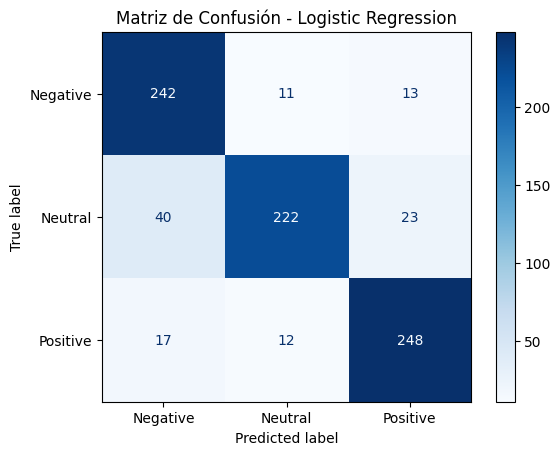

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Matriz del mejor modelo
cm = confusion_matrix(y_val, predicciones_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

In [ ]:
# Probar con tweets nuevos
tweets_prueba = [
    "I love this product, it is amazing!",
    "This is the worst experience I ever had",
    "The weather today is okay I guess"
]

tweets_limpios = [limpiar_texto(t) for t in tweets_prueba]
tweets_vectorizados = vectorizador.transform(tweets_limpios)
predicciones = modelo_lr.predict(tweets_vectorizados)

for tweet, sentimiento in zip(tweets_prueba, predicciones):
    print(f"Tweet: {tweet}")
    print(f"Sentimiento: {sentimiento}\n")

Tweet: I love this product, it is amazing!
Sentimiento: Positive

Tweet: This is the worst experience I ever had
Sentimiento: Negative

Tweet: The weather today is okay I guess
Sentimiento: Positive



In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(modelo_lr, X_train, y_train, cv=5)
print("Validación cruzada:", round(scores.mean() * 100, 2), "%")

Validación cruzada: 54.63 %


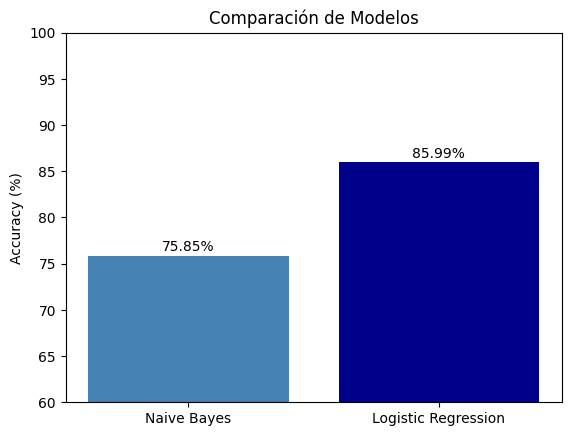

In [ ]:
import matplotlib.pyplot as plt

modelos = ["Naive Bayes", "Logistic Regression"]
accuracies = [75.85, 85.99]

plt.bar(modelos, accuracies, color=["steelblue", "darkblue"])
plt.title("Comparación de Modelos")
plt.ylabel("Accuracy (%)")
plt.ylim([60, 100])

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, str(v) + "%", ha="center")

plt.show()